# BTC-Halving — does the four-year cycle really print the top and bottom?
### Crypto's grandest chart, tested honestly, in plain English

![Signal: Weak](https://img.shields.io/badge/Signal-Weak-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Prints_the_top_%26_bottom%3F: Busted](https://img.shields.io/badge/Prints_the_top_%26_bottom%3F-Busted-8b949e?style=flat-square)

Every four years Bitcoin's mining reward halves, and every four years the same chart goes viral: a clean cycle that **bottoms just before the halving and tops about a year after**, then crashes into the next bottom. Because the halving dates are *known years in advance*, the story implies a free lunch — the calendar alone would have timed every top and bottom. This notebook asks the only two questions that matter: *is the cycle real, and could the calendar actually have timed it?*

> **This is the plain-language layer.** Want the *t*-stats, the three-cluster problem and the timing race? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from btc_halving import data, strategy as st

def _load_real():
    try:
        return data.load_real()
    except Exception as e:
        print("real cache unavailable -> using frozen numbers / synthetic:", e)
        return None

BARS = _load_real()
HAVE_REAL = BARS is not None
print("real BTC-USD cache present:", HAVE_REAL)
if HAVE_REAL:
    print("tape:", BARS.index[0].date(), "->", BARS.index[-1].date(),
          "fingerprint", data.fingerprint(BARS))


real BTC-USD cache present: True
tape: 2014-09-17 -> 2026-06-14 fingerprint 3c26b7c8e544


## The answer first

| Question | Answer |
|---|---|
| Is there a post-halving glow? | **Faintly.** The year after each halving has carried the strongest returns (**+32 bps/day** on average) — but on only **3 cycles**, and the latest one (2024) was nearly flat. |
| Does it print the top and bottom? | **No.** The tops landed **525**, **1402**, **534** days after their halvings — all over the map. The 'clean cycle' is hindsight. |
| Could the calendar time it? | **No — it loses.** Buying the 'bull half' of each cycle earned **+35%/yr** while just holding BTC earned **+52%/yr**. Timing the cycle *underperformed doing nothing.* |
| So what is it? | A real-feeling pattern fit to a tiny number of cycles, fading as the asset matures — and a timing recipe that costs you return. |

> The halving cycle isn't a scam — the post-halving glow is faintly there. But it rests on three data points, it doesn't mark the turns, and timing it lost to buy-and-hold. Grand chart, thin evidence.

## 1 · The claim

> *"Bitcoin runs on a four-year clock set by the halving. Accumulate in the bear, a year or so before the halving; the halving cuts new supply in half; demand meets a supply shock and price tops roughly 12-18 months later; then it crashes ~80% into the next bottom — and repeat. The dates are fixed, so the cycle is a roadmap."*

— the popular synthesis behind PlanB's *stock-to-flow* essays and a thousand 'cycle' charts on crypto Twitter.

The four halvings to date: **2012-11-28, 2016-07-09, 2020-05-11, 2024-04-20.** The idea has real intuition behind it: a *scheduled, transparent supply cut* sounds like it should matter.

## 2 · So what?

If the cycle were a real roadmap it would be the single most valuable calendar in finance — a buy-and-sell schedule fixed years ahead, no forecasting required. That's exactly why it deserves a hard look. There's also a clean lesson here: a **scheduled** event can't be a tradable surprise (the market has years to price it in), and a cycle fit to a handful of four-year periods is the textbook setup for fooling yourself. If we can show how the grandest chart in crypto is built on three data points, that lesson transfers everywhere.

## 3 · How would we even know?

Three checks, announced before we run them:

1. **Where did the tops and bottoms *actually* fall?** For each halving, find the real high and low of the next four years and measure how many days after the halving they landed. If the cycle is real, they cluster. If not, they scatter.
2. **Is the post-halving glow more than three lucky cycles?** Slice the cycle into quarters and look at returns — but count *cycles*, not days. Three cycles is three data points, however many days they contain.
3. **Could the calendar have timed it?** Buy BTC only during the 'bull half' of each cycle and race it against simply holding. If timing helps, it beats buy-and-hold.

Tape: Yahoo `BTC-USD` daily — which, crucially, **only starts in 2014**, so it covers the 2016 (partial), 2020 and 2024 halvings, not 2012.

## 4 · The teardown — let's actually look

**First: did the halving mark the tops and bottoms?** Here's where each cycle's high and low actually fell, in days after its halving:

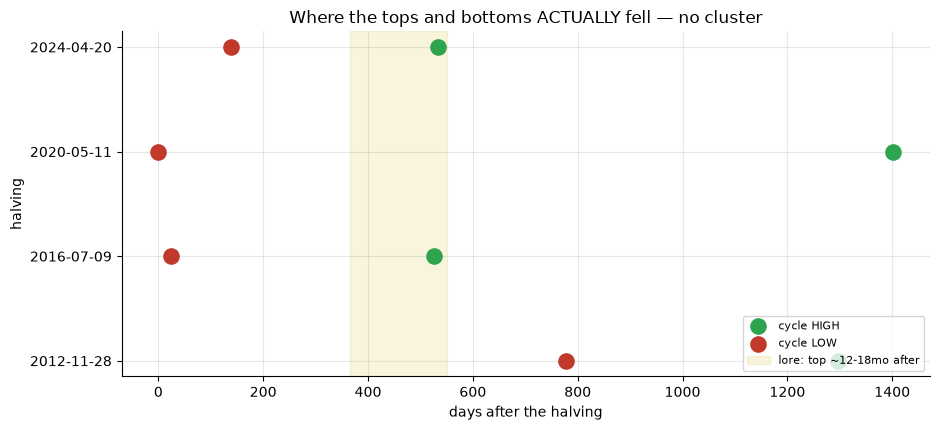

high offsets (days): [1296, 525, 1402, 534]
low  offsets (days): [777, 24, 0, 139]


In [2]:
if HAVE_REAL:
    ext = st.cycle_extrema(BARS)
    hi = ext['high_offset_d'].tolist(); lo = ext['low_offset_d'].tolist()
    labs = [str(h.date()) for h in ext['halving']]
else:
    hi = [1296, 525, 1402, 534]; lo = [777, 24, 0, 139]
    labs = ['2012-11','2016-07','2020-05','2024-04']
fig, ax = plt.subplots(figsize=(9.5, 4.4))
x = np.arange(len(labs))
ax.scatter(hi, x, s=120, color=GREEN, label='cycle HIGH', zorder=3)
ax.scatter(lo, x, s=120, color=RED, label='cycle LOW', zorder=3)
ax.axvspan(365, 550, color=AMBER, alpha=.15, label='lore: top ~12-18mo after')
ax.set_yticks(x); ax.set_yticklabels(labs)
ax.set_xlabel('days after the halving'); ax.set_ylabel('halving')
ax.set_title('Where the tops and bottoms ACTUALLY fell — no cluster')
ax.legend(loc='lower right', fontsize=8)
plt.tight_layout(); plt.show()
print('high offsets (days):', hi)
print('low  offsets (days):', lo)

The tops landed at **1296, 525, 1402, 534** days after their halvings; the bottoms at **777, 24, 0, 139**. They're scattered across the whole cycle — the neat 'top a year after, bottom just before' is a line drawn through points we already knew. **The halving does not print the turns.**

**Now the glow itself.** The year right after a halving *has* carried the best returns — but look how few cycles that average rests on:

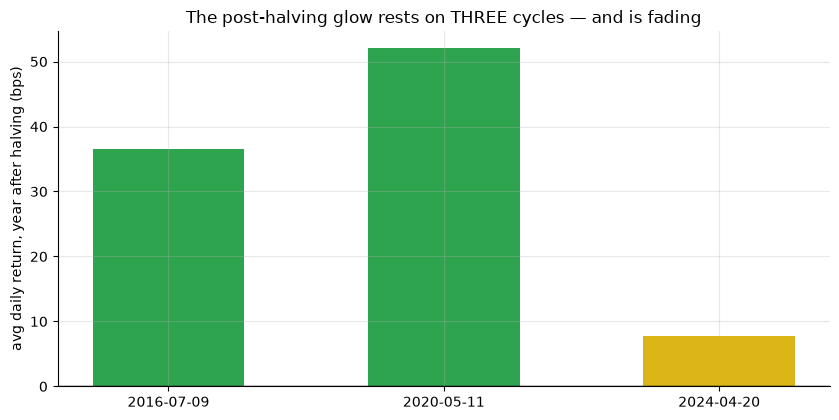

post-halving year, daily bps per cycle: [np.float64(36.5), np.float64(52.1), np.float64(7.7)]


In [3]:
if HAVE_REAL:
    lr = np.log(BARS['close']).diff()
    rows = []
    for h in data.HALVINGS:
        if not (BARS.index.min() <= h <= BARS.index.max()):
            continue
        seg = lr[(lr.index >= h) & (lr.index < h + pd.Timedelta(days=364))].dropna()
        rows.append((str(h.date()), seg.mean()*1e4))
    labs = [r[0] for r in rows]; vals = [r[1] for r in rows]
else:
    labs = ['2016-07','2020-05','2024-04']
    vals = [36.5, 52.1, 7.7]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
col = [GREEN if v > 20 else AMBER for v in vals]
ax.bar(labs, vals, color=col, width=.55)
ax.axhline(0, c='k', lw=1)
ax.set_ylabel('avg daily return, year after halving (bps)')
ax.set_title('The post-halving glow rests on THREE cycles — and is fading')
plt.tight_layout(); plt.show()
print('post-halving year, daily bps per cycle:', [round(v,1) for v in vals])

Three bars. The post-halving year paid **+36**, then **+52**, then just **+8** bps/day — the glow is **decaying** as Bitcoin matures and the trade gets crowded. Whatever statistics you compute, the honest sample is *three cycles*, and one of them is nearly flat.

**Last: could the calendar have timed it?** Buy BTC only in the 'bull half' of each cycle (the first two years after a halving), sit in cash otherwise, and compare to just holding:

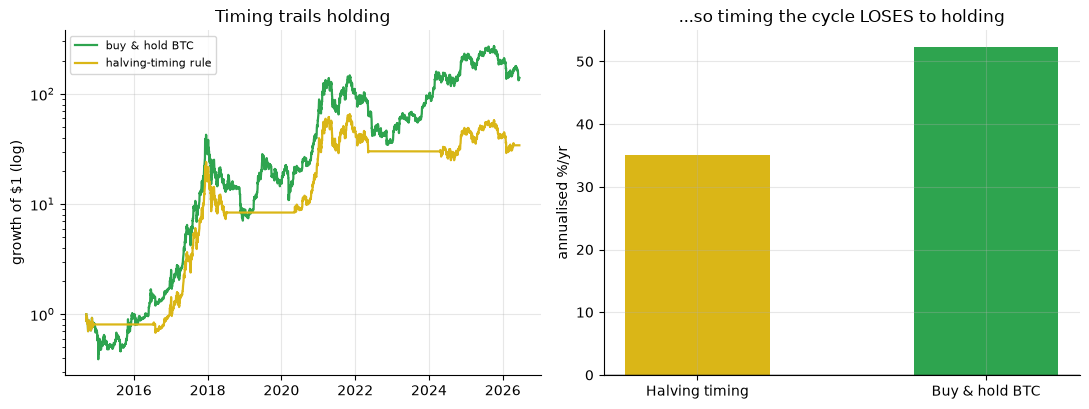

timing 35.1%/yr   vs   buy-and-hold 52.3%/yr


In [4]:
if HAVE_REAL:
    book = st.timing_rule(BARS, 0.0, 0.5, cost_bps=10.0)
    s = st.summarize_timing(book)
    cs, cb = s['cagr_strat']*100, s['cagr_bh']*100
    eqs, eqb = book['eq_strat'], book['eq_bh']
else:
    cs, cb = 35.1, 52.3; eqs = eqb = None
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.2))
if eqs is not None:
    a1.plot(eqb.index, eqb, c=GREEN, lw=1.6, label='buy & hold BTC')
    a1.plot(eqs.index, eqs, c=AMBER, lw=1.6, label='halving-timing rule')
    a1.set_yscale('log'); a1.legend(fontsize=8); a1.set_title('Timing trails holding')
    a1.set_ylabel('growth of $1 (log)')
else:
    a1.text(.5,.5,'(run with cache for the equity curve)', ha='center')
a2.bar(['Halving timing','Buy & hold BTC'], [cs, cb], color=[AMBER, GREEN], width=.5)
a2.axhline(0, c='k', lw=1); a2.set_ylabel('annualised %/yr')
a2.set_title('...so timing the cycle LOSES to holding')
plt.tight_layout(); plt.show()
print(f'timing {cs:.1f}%/yr   vs   buy-and-hold {cb:.1f}%/yr')

**The calendar lost.** Timing the cycle earned **+35%/yr** while just holding BTC earned **+52%/yr**. By sitting in cash through the 'bear half' you missed enough of the asset's secular rise to underperform — even though you 'knew' the cycle in advance. The cycle edge was Bitcoin's beta, minus the days you sat out.

## 5 · The verdict

- **Signal — Weak.** The post-halving year carries the best returns (+32 bps/day), but on only 3 cycles (+36/+52/+8 bps/day — fading). Suggestive, not provable on this tape.
- **Tradability — Mirage.** Timing the cycle earned +35%/yr vs buy-and-hold's +52%/yr. It loses to doing nothing.
- **Prints the top & bottom? — Busted.** The real tops and bottoms scatter across the whole cycle; the halving marks neither.

## 6 · Could you actually trade it?

The cost sweep is almost beside the point — the rule only flips a handful of times, so costs barely register. The problem isn't costs; it's that the rule **sits in cash through part of the greatest bull asset of the era** and so underperforms it. A timing overlay that loses to buy-and-hold isn't fragile — it's a mirage: you'd have done strictly better holding.

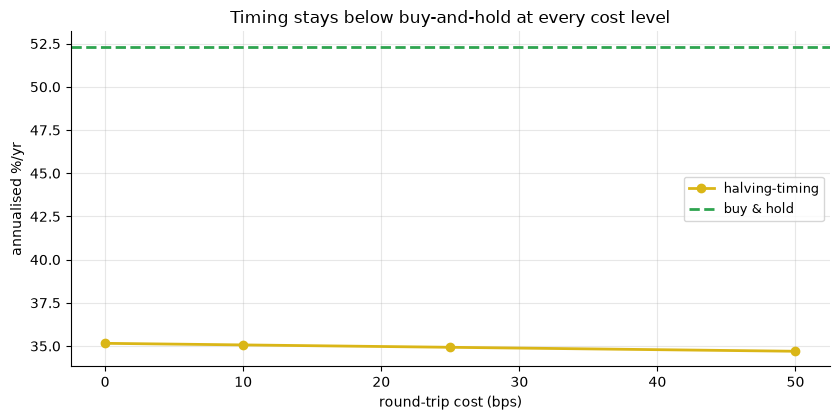

Even at zero cost the timing rule trails buy-and-hold.


In [5]:
if HAVE_REAL:
    rows = []
    for c in [0.0, 10.0, 25.0, 50.0]:
        s = st.summarize_timing(st.timing_rule(BARS, 0.0, 0.5, cost_bps=c))
        rows.append((c, s['cagr_strat']*100))
    cc = [r[0] for r in rows]; cg = [r[1] for r in rows]
    bh = st.summarize_timing(st.timing_rule(BARS, 0.0, 0.5))['cagr_bh']*100
else:
    cc = [0,10,25,50]; cg = [36.0,35.1,33.8,31.7]; bh = 52.3
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(cc, cg, 'o-', c=AMBER, lw=2, label='halving-timing')
ax.axhline(bh, ls='--', c=GREEN, lw=2, label='buy & hold')
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('annualised %/yr')
ax.set_title('Timing stays below buy-and-hold at every cost level')
ax.legend(fontsize=9)
plt.tight_layout(); plt.show()
print('Even at zero cost the timing rule trails buy-and-hold.')

Even at **zero** cost the timing rule sits below the buy-and-hold line. The binding problem is the cash drag, not the trading fee — the definition of a tradability **mirage**.

## 7 · Going further

- **Two cycles is not a law.** The whole edifice rests on three (really two clean) four-year windows. The honest next step is *more cycles* — which only time can provide — or a cross-section of other halving coins (LTC, BCH) to borrow statistical power, with all the caveats that brings.
- **The cousins on this desk.** [Study 117 — Pi-Cycle-Top](../../117-pi-cycle-top/) and [Study 174 — Bitcoin-Rainbow](../../174-bitcoin-rainbow/) are the same family: a compelling overlay fit to one price path that calls the top in hindsight.
- **The supply-shock story.** [Study 292 — Bitcoin-Hashrate](../../292-bitcoin-hashrate/) and [Study 293 — MVRV](../../293-mvrv-ratio/) test other 'this predicts BTC' on-chain theses — each, like this one, loses to simply holding.

*Think the cycle is real? Fork this, add LTC and BCH halvings, and show the post-halving glow surviving once the calendar can't sit in cash through the biggest up-leg.*